In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(*args, **kwargs): pass

PROJECT_ROOT = os.path.abspath('..')


## CONFIG — change simulation date and filters here

In [26]:
# === INPUT CONFIGURATION — edit these to run for a different line / scenario ===
LINE_NUM          = "6"                        # line number or name
LINE_CODE         = f"bjl{LINE_NUM}"           # prefix used in output filenames

# Folders (relative to PROJECT_ROOT)
RAW_DATA_DIR      = "raw_data"
OUTPUT_DIR        = "transit_sim_inputs"
FIGS_DIR          = "figs"

# Input files
SMARTCARD_FILE     = "smart_card_data.csv"
STATION_CODES_FILE = "station_codes.csv"               # shared with 0001

# Simulation parameters
SIM_DATE          = '2026-06-24'               # date of smartcard records
MIN_TRAVEL_MIN    = 5                          # filter: min trip duration (min)
MAX_TRAVEL_MIN    = 300                        # filter: max trip duration (min)
DEAL_STATUS_EXIT  = [2]                        # AFC status code for exit tap
AM_HOUR_START     = 5                          # ] morning window for
AM_HOUR_END       = 12                         # ] daily-count chart
DASHED_STATION    = 'beiyunhexi'               # station shown with dash-dot in demand plot

# Derived — no need to edit
OD_YEAR = int(SIM_DATE[:4])
OD_OUT  = f"od_{LINE_CODE}_{SIM_DATE}.csv"
FIG_OUT = f"{LINE_CODE}_od_{SIM_DATE}.png"

## Load and filter smartcard data

In [27]:
smartcard_file = os.path.join(PROJECT_ROOT, RAW_DATA_DIR, SMARTCARD_FILE)
print(f'Loading {smartcard_file} ...')

usecols = ['SMART_CARD_ID','ENTRY_TIME','EXIT_TIME','DEAL_STATUS',
           'TRIP_ORIGIN_LOCATION','TRIP_DESTINATION_LOCATION']
od = pd.read_csv(smartcard_file, usecols=usecols)

od = od[od['DEAL_STATUS'].isin(DEAL_STATUS_EXIT)].copy()
od['ENTRY_TIME'] = pd.to_datetime(od['ENTRY_TIME'])
od['EXIT_TIME']  = pd.to_datetime(od['EXIT_TIME'])
od['entry_time'] = od['ENTRY_TIME'].dt.strftime('%H:%M:%S')
od['deal_time']  = od['EXIT_TIME'].dt.strftime('%H:%M:%S')
od['hour']       = od['ENTRY_TIME'].dt.hour
od['date']       = od['ENTRY_TIME'].dt.date.astype(str)
od['weekday']    = od['ENTRY_TIME'].dt.weekday
od['year']       = od['ENTRY_TIME'].dt.year
od['month']      = od['ENTRY_TIME'].dt.month

od = od[
    od['year'].isin([OD_YEAR]) &
    (od['EXIT_TIME'] > od['ENTRY_TIME'])
].copy()

od['travel_time'] = ((od['EXIT_TIME'] - od['ENTRY_TIME']).dt.total_seconds()/60).round()
od = od[(od['travel_time'] > MIN_TRAVEL_MIN) & (od['travel_time'] < MAX_TRAVEL_MIN)]

print(od.shape)
od.head(1)

Loading /Users/suryabuchunde/Data/AAAM/raw_data/smart_card_data.csv ...
(158968, 14)


,SMART_CARD_ID,ENTRY_TIME,EXIT_TIME,DEAL_STATUS,TRIP_ORIGIN_LOCATION,TRIP_DESTINATION_LOCATION,entry_time,deal_time,hour,date,weekday,year,month,travel_time
0,1,2026-06-24 07:39:00,2026-06-24 08:23:56,2,100000149,100000102.0,07:39:00,08:23:56,7,2026-06-24,2,2026,6,45.0


## Map station codes to names

In [28]:
station_codes_df = pd.read_csv(os.path.join(PROJECT_ROOT, RAW_DATA_DIR, STATION_CODES_FILE))
code_to_station = dict(zip(station_codes_df["afc_code"], station_codes_df["station_name"]))
print(f'Station mapping: {len(code_to_station)} stations across all lines')

# Keep all trips whose origin is on the line; out-of-network exits are marked
# 'out_of_network' and will be remapped to the terminal station in the simulation notebook.
od = od[od['TRIP_ORIGIN_LOCATION'].isin(code_to_station)].copy()
od['enter_station'] = od['TRIP_ORIGIN_LOCATION'].map(code_to_station)

od['exit_type'] = np.where(
    od['TRIP_DESTINATION_LOCATION'].isin(code_to_station),
    np.where(od['TRIP_DESTINATION_LOCATION'] < od['TRIP_ORIGIN_LOCATION'], 1, 0),
    1   # out-of-network exits treated as downward (passenger travels west to jintai_lu)
)
od['exit_station'] = np.where(
    od['TRIP_DESTINATION_LOCATION'].isin(code_to_station),
    od['TRIP_DESTINATION_LOCATION'].map(code_to_station),
    'out_of_network'
)

od = od[od['enter_station'] != od['exit_station']].reset_index(drop=True)

print(od.shape)
display(od.head(1))
display(od.groupby('exit_type').size())

Station mapping: 354 stations across all lines
(158617, 17)


,SMART_CARD_ID,ENTRY_TIME,EXIT_TIME,DEAL_STATUS,TRIP_ORIGIN_LOCATION,TRIP_DESTINATION_LOCATION,entry_time,deal_time,hour,date,weekday,year,month,travel_time,enter_station,exit_type,exit_station
0,1,2026-06-24 07:39:00,2026-06-24 08:23:56,2,100000149,100000102.0,07:39:00,08:23:56,7,2026-06-24,2,2026,6,45.0,changying,1,huixinxijienankou


exit_type
0    70831
1    87786
dtype: int64

## Daily trip count — check SIM_DATE exists

2026-06-24: 158617 trips


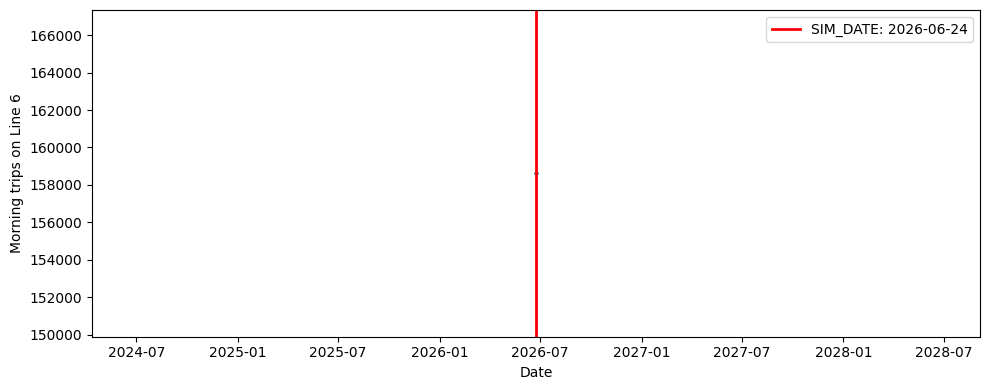

In [29]:
daily_cnt = od[od['hour'].isin(range(AM_HOUR_START, AM_HOUR_END))].groupby('date').size().to_frame('am_trips').reset_index()
dates = np.array(daily_cnt['date'], dtype='datetime64[ms]')

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(dates, daily_cnt['am_trips'], s=5)
ax.axvline(np.datetime64(SIM_DATE), color='r', lw=2, label=f'SIM_DATE: {SIM_DATE}')
ax.set_xlabel('Date')
ax.set_ylabel(f'Morning trips on Line {LINE_NUM}')
ax.legend()
plt.tight_layout()

if SIM_DATE not in od['date'].values:
    print(f'WARNING: {SIM_DATE} not in data!')
    print('Available sample:', sorted(od["date"].unique())[:5])
else:
    print(f'{SIM_DATE}: {od[od["date"]==SIM_DATE].shape[0]} trips')

## Extract one-day OD and save

In [30]:
od_day = od[od['date'] == SIM_DATE].copy().reset_index(drop=True)

rng = np.random.default_rng(seed=0)
h = od_day['entry_time'].str[:2].astype(int)
m = od_day['entry_time'].str[3:5].astype(int)
od_day['departure_time'] = h * 3600 + m * 60 + rng.integers(0, 60, len(od_day))

# Rename columns to match run_transit_sim.py expectations
out_df = od_day[['SMART_CARD_ID','date','weekday','hour',
                  'entry_time','deal_time','enter_station','exit_station',
                  'travel_time','exit_type','departure_time']].rename(columns={
    'enter_station': 'in.station',
    'exit_station':  'out.station',
    'departure_time': 'in.time',
})

os.makedirs(os.path.join(PROJECT_ROOT, OUTPUT_DIR), exist_ok=True)
out_path = os.path.join(PROJECT_ROOT, OUTPUT_DIR, OD_OUT)
out_df.to_csv(out_path, index=False)
print(f'Saved {len(out_df)} trips → {out_path}')
display(out_df.head(2))

Saved 158617 trips → /Users/suryabuchunde/Data/AAAM/transit_sim_inputs/od_bjl6_2026-06-24.csv


,SMART_CARD_ID,date,weekday,hour,entry_time,deal_time,in.station,out.station,travel_time,exit_type,in.time
0,1,2026-06-24,2,7,07:39:00,08:23:56,changying,huixinxijienankou,45.0,1,27591
1,2,2026-06-24,2,8,08:25:29,09:36:46,huangqu,ciqunan,71.0,1,30338


## Demand profile plot

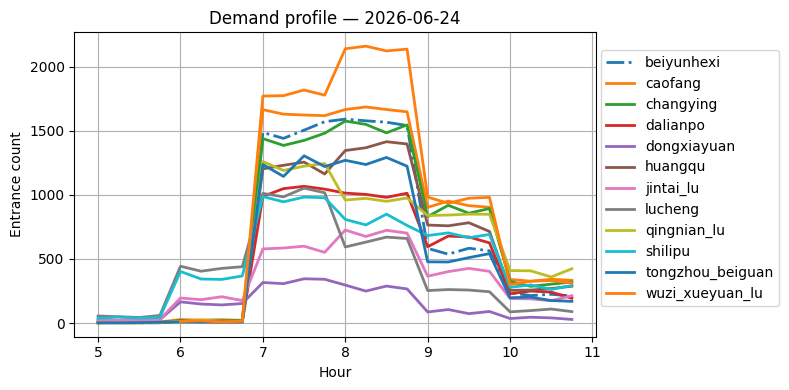

In [31]:
out_df['departure_category'] = out_df['in.time'] // 900 * 0.25
tmp = out_df.groupby(['departure_category', 'in.station']).size().to_frame('count').reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
for nm, grp in tmp.groupby('in.station'):
    ls = '-.' if nm == DASHED_STATION else '-'
    ax.plot(grp['departure_category'].values, grp['count'].values, lw=2, label=nm, ls=ls)
ax.grid()
ax.set_xlabel('Hour')
ax.set_ylabel('Entrance count')
ax.set_title(f'Demand profile — {SIM_DATE}')
plt.legend(loc=[1.01, 0.1])
plt.tight_layout()

figs_dir = os.path.join(PROJECT_ROOT, FIGS_DIR)
os.makedirs(figs_dir, exist_ok=True)
plt.savefig(os.path.join(figs_dir, FIG_OUT), dpi=300, bbox_inches='tight')

## Weekly statistics

In [32]:
od_daily_cnt = od.groupby(['date','weekday']).size().to_frame('count').reset_index()
display(od_daily_cnt.groupby('weekday')['count'].agg(['mean','std']).round(0))
display(od_daily_cnt.sort_values('count', ascending=False).head())


,mean,std
weekday,,
2,158617.0,NaN


,date,weekday,count
0,2026-06-24,2,158617
